<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
    Herramientas Computacionales Avanzadas
  </span>
  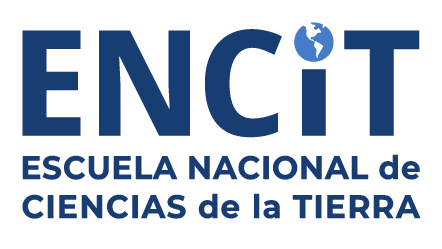
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema 2: Manejo de datos</span><br/>
  <span style="color:DodgerBlue; font-size:140%;">Notebook: Gráficas avanzadas </span><br/>
  <span style="font-size:100%;color:forestgreen"> Escuela Nacional de Ciencias de la Tierra  |  Semestre 2026-II</span>
</p>

---


Después de revisar en la Unidad I los principios básicos para generar gráficos con *Matplotlib*, es posible avanzar hacia visualizaciones más complejas que permiten analizar los datos con mayor profundidad. En esta clase se introducirán algunos gráficos avanzados como:

* **Histogramas de frecuencia**: permiten estudiar la distribución de una variable.
* **Diagramas de caja o gráficos de bigotes**: dispersión de los datos mediante cuartiles.
* **Mapas de calor**: visualizar la variación de valores en matrices o campos bidimensionales.
*  **Gráficos de contorno**: útiles para representar campos continuos o superficies.

Estos tipos de gráficos amplían las posibilidades de análisis y ayudan a representar la información de forma más clara y detallada.

--------------------

In [2]:
#Primero vamos a importar todas las paqueterías necesarias para la clase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## <font color="darkblue"> **Histogramas de frecuencia**

Un *histograma* es una representación gráfica que nos permite ver la **distribución de las frecuencias de una muestra numérica**. Consiste en **dividir el rango de los datos en intervalos o clases (bins)** y contar cuántos datos caen dentro de cada intervalo. En apariencia, es similar a un gráfico de barras, sin embargo, en lugar de comparar categorías, *cada barra de un histograma representa cómo se distribuyen los datos en una única categoría*.

**Un histograma está compuesto por**:

* *Eje x*: intervalos de valores (bins o clases).

* *Eje y*: frecuencia (número de datos dentro del intervalo).

* *Barras*: representan la cantidad de observaciones en cada intervalo.

<p align="center">
  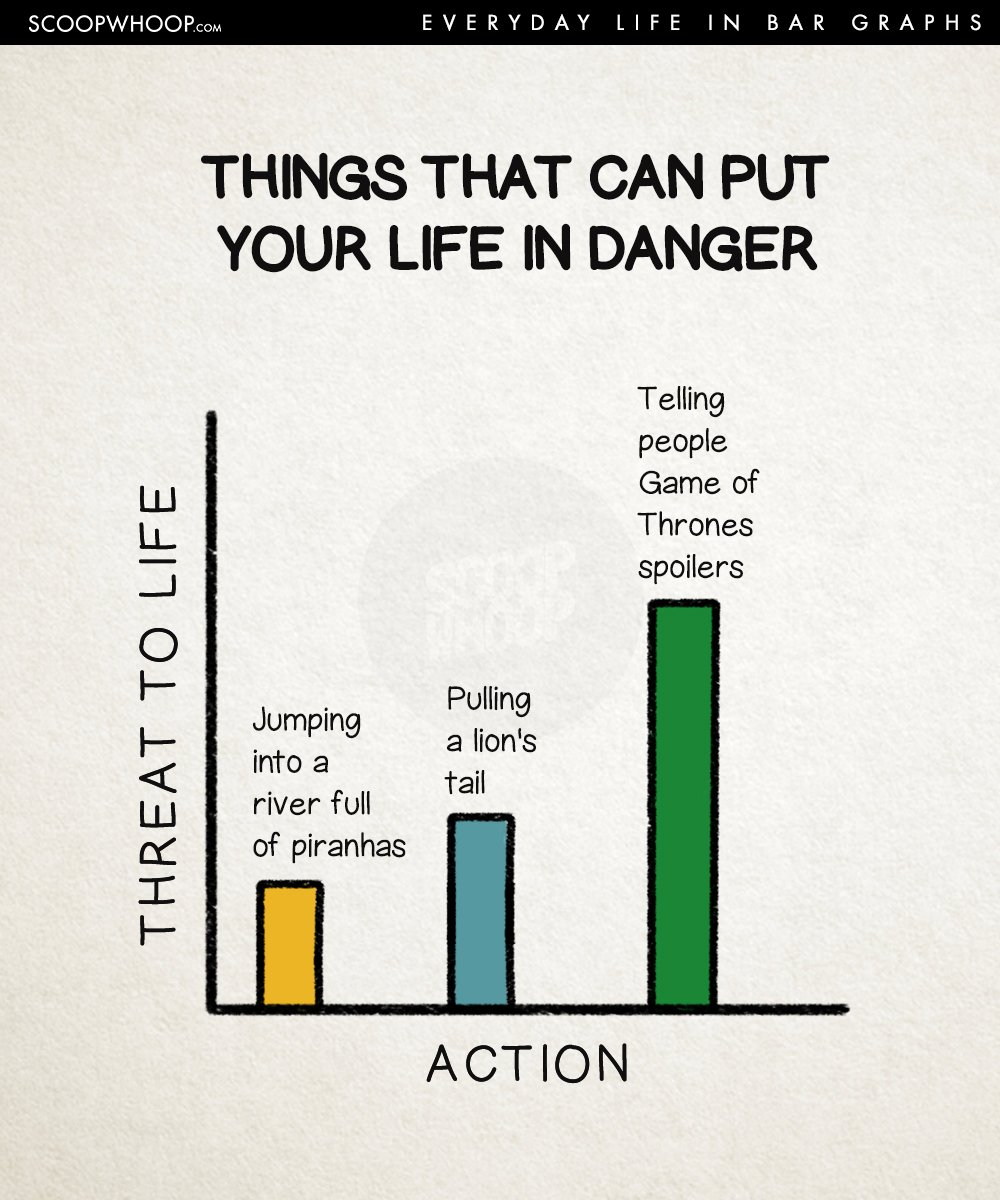
</p>

#### <font color="olive"> **¿Para qué sirve un histograma?**

* Analizar la distribución de los datos.

* Identificar asimetría (sesgo).

* Observar si los datos siguen una distribución conocida (por ejemplo, normal).

* Comparar distribuciones entre conjuntos de datos.

#### <font color="olive"> **¿Cómo creamos un histograma con *Matplotlib*?**

Matplotlib cuenta con la función`.hist()` que permite graficar histogramas (<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html>). Sin embargo, a diferencia de los otros tipos de plots que hemos visto, <font color="brown"> **los histogramas no se pueden plotear directamente </font>**. Por lo que, *para crear un histograma es necesario seguir los pasos siguientes*:


1. Determinar los intervalos a representar, de tal manera que no se solapen.

2. Calcular la frecuencia de cada intervalo.

3. Una vez que tenemos los intervalos y las frecuencias calculadas solo resta hacer alguna representación gráfica.

---

Ahora sí, con este contexto vamos a crear nuestro primer histograma. 

#### <font color="darkorange"> **Paso 1 y Paso 2: Intervalos a representar y frecuencia de cada uno**

Tenemos una lista con diferentes edades y queremos conocer la frecuencia de dichas edades en 8 intervalos diferentes.

In [3]:
Edades=[12, 15, 13, 12, 18, 20, 19, 20, 13, 12, 13, 17, 15, 16, 13, 14, 13, 17, 19]

#Queremos dividir esa lista en 8 intervalos diferentes
#Podemos dividir en intervalos de dos maneras diferentes: (1) Definiendo la cantidad de intervalos, (2) Definiendo los límites de cada intervalo

#### <font color="darkblue"> Forma 1: Definiendo la cantidad de intervalos

**`np.histogram()`** 
</font>(<https://numpy.org/doc/stable/reference/generated/numpy.histogram.html>)

La función `np.histogram()` de NumPy cuenta cuántos valores caen dentro de determinados intervalos (bins). A diferencia de `plt.hist()`, *np.histogram()* no genera una gráfica, sino que devuelve los conteos y los límites de los intervalos, lo cual resulta útil cuando se quiere realizar un análisis previo de los datos o construir gráficos personalizados.

In [4]:
#Forma 1:
# Necesitamos dos parámetros de entrada: Los datos y cuántos intervalos queremos
frecuencias= np.histogram(Edades, bins = 8) #Este bins nos ayuda a determinar los intervalos que queremos analizar

#¿Qué tipo de datos nos regresa?
print(frecuencias) # Es importante notar que cada intervalo incluye el límite inferior 
                   # y excluye el superior, excepto el último intervalo, que incluye ambos límites.

(array([3, 5, 1, 2, 1, 2, 1, 4]), array([12., 13., 14., 15., 16., 17., 18., 19., 20.]))


In [5]:
#Ahora quiero guardar por separado lo que regresa la función, ¿Cómo le hacemos?


In [6]:
#¿Y si quiero que el valor 19 y 20 se cuenten por separado?
#Para ello usamos el argumento "range" dentro de la función histogram()

frecuencias2=np.histogram(Edades,bins=9,range=(12,21)) #"range" permite definir el rango de valores a considerar
frecuencias2

(array([3, 5, 1, 2, 1, 2, 1, 2, 2]),
 array([12., 13., 14., 15., 16., 17., 18., 19., 20., 21.]))

#### <font color="darkblue"> Forma 2: Personalizar límites de los bins

In [7]:
# ¿Qué pasa si quieren hacer rangos personalizados?
# [10, 13) [13, 15) [15, 20]

frecuencia3, intervalos3 = np.histogram(Edades, bins=(10, 13, 15, 20)) # Puede ser con tupla o con lista, es importante que sus intervalos vayan incrementando
print(frecuencia3, intervalos3) 

[ 3  6 10] [10 13 15 20]


**Pueden personalizar sus bins definiéndolos directamente antes de graficar**

In [8]:
intervalos=[10,13,16,19,22] #¿Y su frecuencia?

#### <font color="darkorange"> Ahora sí, ¡Vamos a graficar! 

#### <font color="darkorange"> **Ejemplo 1**


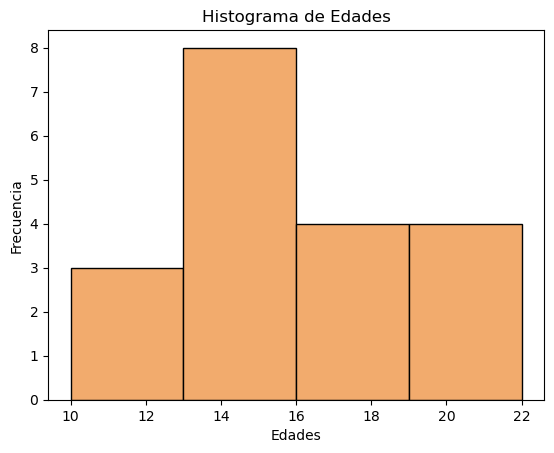

In [9]:
#Contorno a cada barra
plt.hist(x = Edades, bins = intervalos, color = '#F2AB6D', rwidth = 1, edgecolor="black")
plt.title('Histograma de Edades')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')
plt.show()

#### <font color="darkorange"> **Ejemplo 2: Frecuencias acumuladas**

[6 3 3 4] [13 15 17 19 21]


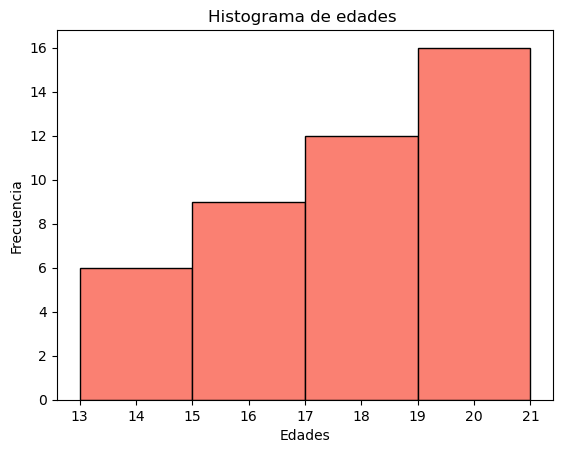

In [10]:
#También podemos acumular las frecuencias de los intervalos

intervalos5 = [13, 15, 17, 19, 21] # Defino mis intervalos

plt.hist(x = Edades, bins = intervalos5, color = 'salmon', cumulative = True,edgecolor="black") #, cumulative = True este hace que vaya acumulando los resultados para cada intervalo
plt.title('Histograma de edades ')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')

#np.histogram les puede servir para corroborar lo que están graficando
frecuencias_p, extremos_p = np.histogram(Edades, bins = intervalos5)
print(frecuencias_p, extremos_p) # Esto les puede servir para corroborar

### <font color="brown"> Histogramas con varios grupos de datos

#### <font color="darkorange">Ejemplo 1: Grupos con el mismo rango de valores

([<matplotlib.axis.XTick at 0x712fce191910>,
 [Text(10, 0, '10'),
  Text(13, 0, '13'),
  Text(16, 0, '16'),
  Text(19, 0, '19'),
  Text(22, 0, '22')])

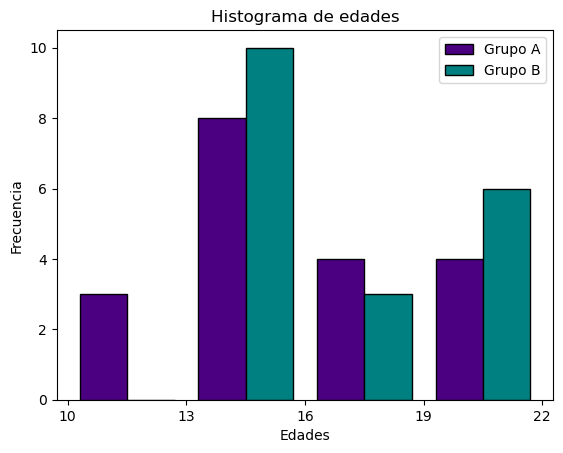

In [11]:
Edades_a = [12, 15, 13, 12, 18, 20, 19, 20, 13, 12, 13, 17, 15, 16, 13, 14, 13, 17, 19]
Edades_b = [20, 19, 17, 15, 15, 16, 13, 13, 19, 20, 20, 14, 15, 15, 18, 19, 13, 14, 15]

intervalos=[10, 13, 16, 19, 22]

#Cuando tengamos más de un grupo, debo de hacer un vector de las X y los colores
plt.hist(x = [Edades_a, Edades_b], bins = intervalos, color = ['indigo' , 'teal'],label=["Grupo A", "Grupo B"], edgecolor="black") 
plt.title('Histograma de edades')
plt.xlabel('Edades')
plt.legend()
plt.ylabel('Frecuencia')
plt.xticks(intervalos)

#### <font color="darkorange">Ejemplo 2: Grupos con diferentes rangos de valores

Text(0.5, 1.0, 'Histogramas de varios grupos')

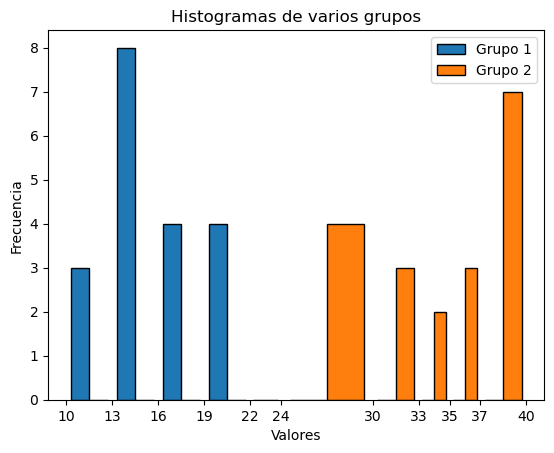

In [12]:
Edades_j = [12, 15, 13, 12, 18, 20, 19, 20, 13, 12, 13, 17, 15, 16, 13, 14, 13, 17, 19]
Edades_a = [33, 35, 28, 40, 37, 31, 25, 33, 28, 37, 40, 31, 35, 35, 28, 40, 37, 31, 40]

intervalos=[10, 13, 16,19,22,24,30,33,35,37,40]

#Podemos graficar datos diferentes en una misma línea
plt.hist([Edades_j, Edades_a], bins=intervalos,edgecolor="black",label=["Grupo 1","Grupo 2"])
plt.xlabel("Valores")
plt.ylabel("Frecuencia")
plt.legend()
plt.xticks(intervalos)
plt.title("Histogramas de varios grupos")

**¿Cómo lo interpretarían?**

El gráfico evidencia dos poblaciones con rangos de edad completamente diferentes, lo que produce dos distribuciones separadas en el histograma. Esto indica que los grupos pertenecen a etapas de edad distintas, sin solapamiento entre ellas. 

<font color="brown"> OJO: Elegir el número correcto de bins es importante porque afecta la interpretación. Muy pocos bins: se pierde información. Demasiados bins: el gráfico se vuelve ruidoso.

### <font color="darkblue"> **Barras apiladas**

En los histogramas, las barras apiladas permiten mostrar varios grupos de datos en los mismos intervalos, pero en lugar de superponerse, las frecuencias de cada grupo se suman verticalmente dentro de cada bin. Esto facilita observar la contribución de cada grupo al total de datos en cada intervalo.

Las barras apiladas se obtienen utilizando el parámetro `stacked=True` en la función `plt.hist()`.

Text(0.5, 1.0, 'Frecuencia de datos')

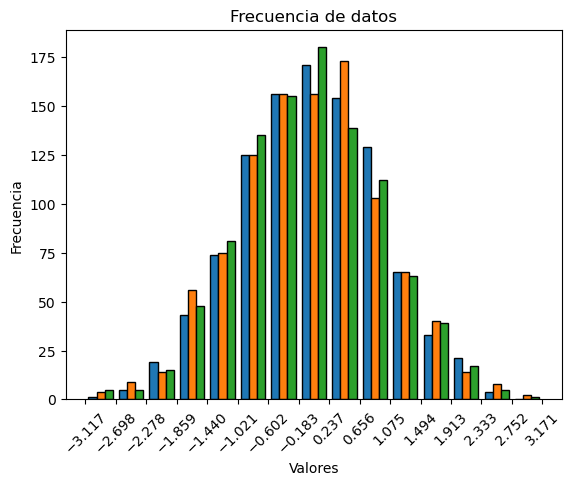

In [13]:
# Crearemos un array de números aleatorios 
np.random.seed(0)
x = np.random.randn(1000,3) #1000 filas  y 3 columnas (Por lo tanto son 3 grupos diferentes)

_,inter=np.histogram(x,bins=15)

plt.hist(x,bins=inter,edgecolor="black") 
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.xticks(inter,rotation=45)
plt.title('Frecuencia de datos')

Text(0.5, 1.0, 'Frecuencia de datos')

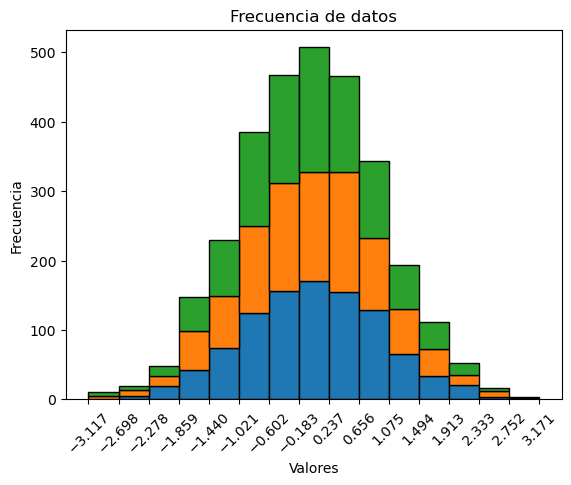

In [14]:
# stacked= True hace que se encime uno en otro
_,inter=np.histogram(x,bins=15)

plt.hist(x,bins=inter,edgecolor="black",stacked=True) 
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.xticks(inter,rotation=45)
plt.title('Frecuencia de datos')

<font color="brown">**Resumen de diferencias entre histogramas y gráficos de barra**

|Histograma|Gráfico de barras|
|-----------|-------|
|Datos continuos|Datos categóricos|
|Barras pegadas	|Barras separadas|
|Intervalos|Categorías|


-----
### <font color="purple">  Ejercicio 1: Días con lluvia por estación</font>

1. Genera con numpy un arreglo con el número de días con lluvia en las cuatro estaciones del año.
2. Define una lista con los nombres de las estaciones: Primavera, Verano, Otoño, Invierno.
3. Haz un gráfico de barras con esos datos.
4. Personaliza la figura con título, etiquetas de ejes y rotación de nombres en el eje x.

Puedes basarte en este código para los 4 días de lluvia.

In [15]:
np.random.seed(42)

estaciones = ["Primavera", "Verano", "Otoño", "Invierno"]
dias_lluvia = np.random.randint(5, 25, size=4)

------------

# <font color="darkblue"> Gráfico de bigotes (boxplot)

Los gráficos de bigotes son una herramienta utilizada para **resumir la distribución de un conjunto de datos mediante medidas estadísticas clave**.
*Este tipo de gráfico muestra el valor mínimo, el primer cuartil (Q1), la mediana, el tercer cuartil (Q3) y el valor máximo*, lo que **permite visualizar de manera rápida la tendencia central, la dispersión y la presencia de valores atípicos (outliers)**. 

<p align="center">
  <img src="https://datavizcatalogue.com/ES/metodos/images/anatomy/SVG/diagrama_cajas_y_bigotes.svg" width="450">
</p>
    

#### <font color="olive"> **¿Para qué sirve un boxplot?**

* Identificar la tendencia central de los datos mediante la mediana.

* Analizar la variabilidad o dispersión de los datos.

* Detectar valores atípicos que pueden representar errores o eventos extremos.

* Comparar rápidamente múltiples conjuntos de datos.

 #### <font color="olive"> **¿Cómo creamos un boxplot?** 

En Matplotlib, estos gráficos se pueden generar fácilmente con la función `plt.boxplot()` (<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html>).

¡Vamos a hacer nuestra primera gráfica de bigotes! :)

#### <font color="darkorange"> **Ejemplo 1: Humedad del suelo**

In [16]:
#Vamos a crear valores random de humedad del suelo
np.random.seed(42)
humedad= np.random.uniform(35, 50, 100)

**Antes de graficar, podemos conocer el comportamiento de los datos mediante los cuartiles. Para ello, usamos la función `quantile()` de NumPy.**

In [17]:
#Cuartile
quantiles = np.quantile(humedad, np.array([0.00, 0.25, 0.50, 0.75, 1.00])) #(datos,cuantiles que quiero conocer)

print(quantiles)

[35.08283176 37.89801141 41.96213682 45.95304679 49.80330405]


In [19]:
#Vamos a agregar valores atípicos a nuestros datos de humedad
outliers=np.array([80.0,75.0,60.0])

#Vamos a unir nuestro array original con los outliers
humedad_extremos = np.concatenate([humedad, outliers]) #np.concatenate() nos permite unir arrays en uno solo

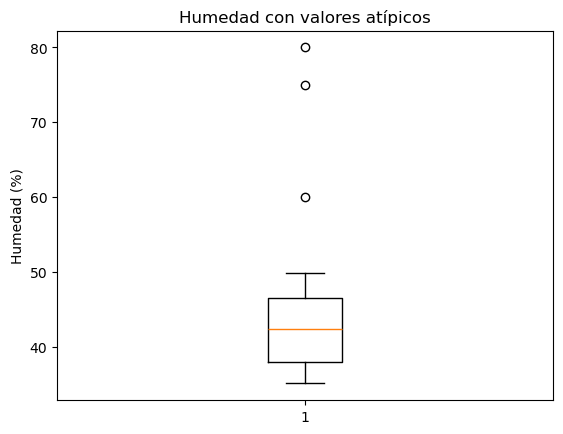

In [20]:
plt.boxplot(humedad_extremos)

plt.title("Humedad con valores atípicos")
plt.ylabel("Humedad (%)")

#### <font color="orange"> **Ejemplo 2: Varios grupos de datos**

In [45]:
#Vamos a crear valores random de humedad del suelo
np.random.seed(5)
humedad_bosque = np.random.uniform(35, 50, 100)
humedad_pastizal = np.random.uniform(25, 40, 100)
humedad_agricola = np.random.uniform(15, 35, 100)

#Vamos a agregar algunos outliers

humedad_bosque=np.concatenate([humedad_bosque,np.array([69,60])])
humedad_pastizal=np.concatenate([humedad_pastizal,np.array([69,75])])
humedad_agricola=np.concatenate([humedad_agricola,np.array([50,65])])

Text(0, 0.5, 'Humedad (%)')

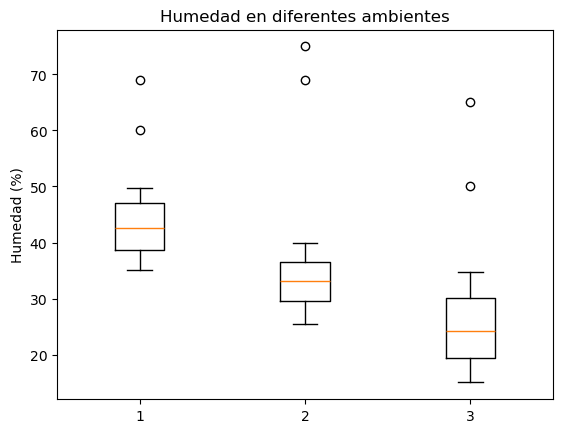

In [46]:
#Ahora vamos a graficarlo

#Paso 1: Crear una lista con los datos a graficar

datos=[humedad_bosque,humedad_pastizal,humedad_agricola]

#Paso2: Graficar

plt.boxplot(datos)
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")


### <font color="darkblue"> **Personalización de los boxplots**

#### <font color="darkorange"> **Ejemplo 1: Etiquetas**

Text(0, 0.5, 'Humedad (%)')

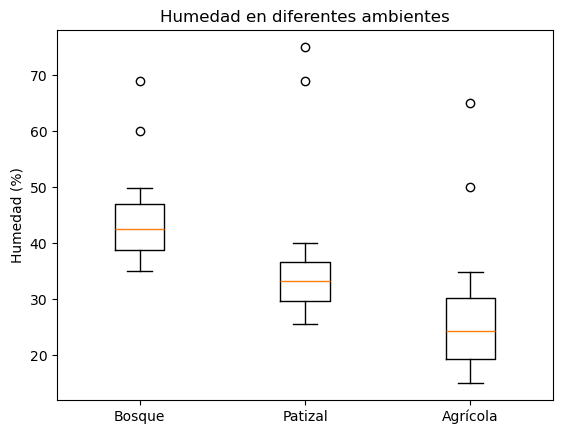

In [23]:
# Etiquetas

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"])
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")


#### <font color="darkorange"> **Ejemplo 2: Orientación**

Text(0.5, 0, 'Humedad (%)')

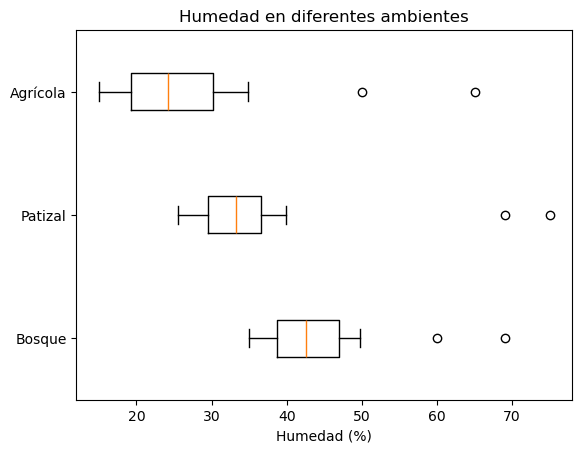

In [24]:
#Orientación del gráfico

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],vert=False) #False: Horizontal, True: Vertical
plt.title("Humedad en diferentes ambientes")
plt.xlabel("Humedad (%)")

#### <font color="darkorange"> **Ejemplo 3: Media y valores atípicos**

Text(0, 0.5, 'Humedad (%)')

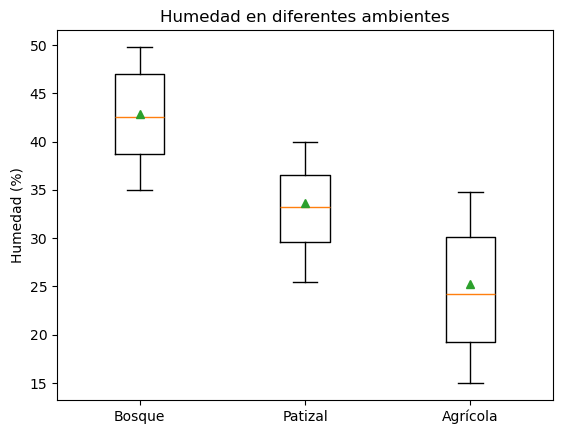

In [25]:
#Mostrar la media de los datos(showmeans), quitar valores atípicos (showfliers)

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],
            vert=True,
           showmeans=True, #La media aparece como un símbolo adicional dentro del boxplot
           showfliers=False  #False quita los outliers
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")

#### <font color="darkorange"> **Ejemplo 4: Estilos de cajas y media**

Text(0, 0.5, 'Humedad (%)')

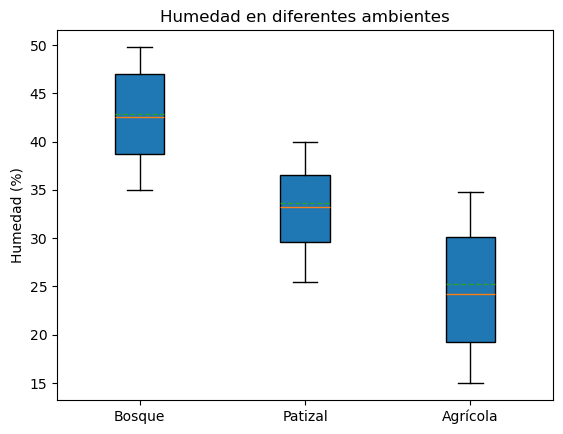

In [26]:
# Quiero colorear las cajas y cambiar el símbolo de la media por una línea

plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],
            vert=True,
           showmeans=True, #La media aparece como un símbolo adicional dentro del boxplot
           showfliers=False,  #False quita los outliers
           patch_artist=True, #Colorear las cajas
            meanline=True #Colocar línea punteada el valor del promedio
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")

#### <font color="darkorange"> **Ejemplo 5: Colores**

Text(0, 0.5, 'Humedad (%)')

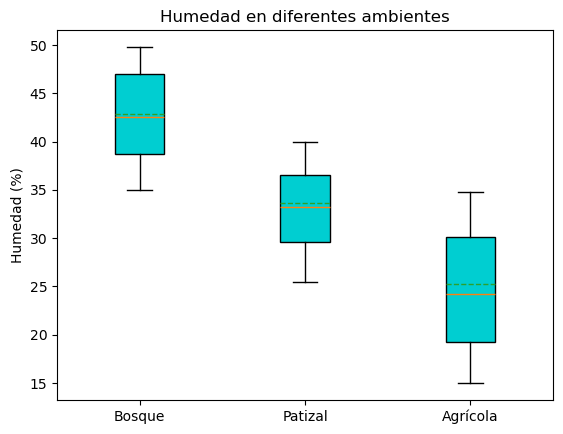

In [27]:
#Colores específicos

# Para cambiar los colores es muy importante poner el patch_artist si no, nos va a salir un error
plt.boxplot(datos, tick_labels=["Bosque","Patizal","Agrícola"],
            vert=True,
           showmeans=True,
           showfliers=False,  
           patch_artist=True, 
            meanline=True,
            boxprops = dict(facecolor= 'darkturquoise') #Personalizar los col
           ) 
plt.title("Humedad en diferentes ambientes")
plt.ylabel("Humedad (%)")

<font color="brown"> **Cuando hay valores `NaN` en los datos, los boxplots en Matplotlib pueden comportarse de dos formas: pueden ignorar automáticamente algunos valores o el gráfico puede no mostrarse correctamente si hay muchos `NaN`. Por eso normalmente se recomienda eliminarlos  antes de hacer el gráfico.**

### <font color="purple"> **Ejercicio 2**

Utilizando los datos de sismos de la clase de Pandas:

* Haz un boxplot de la magnitud de los sismos.
* Identifica los 'outliers'.
* Personaliza tu gráfica lo más que puedas.


-------

## <font color="darkblue"> **Mapas de calor (heatmaps)**

Los **mapas de calor** (heatmaps) son un tipo de visualización que permite **representar la magnitud de los valores de una variable mediante colores en una matriz o en un espacio bidimensional**. En este tipo de gráfico, cada celda o punto del plano se colorea de acuerdo con el valor de la variable que se desea representar, utilizando una escala de colores que facilita la identificación de patrones, gradientes y zonas con valores altos o bajos. 

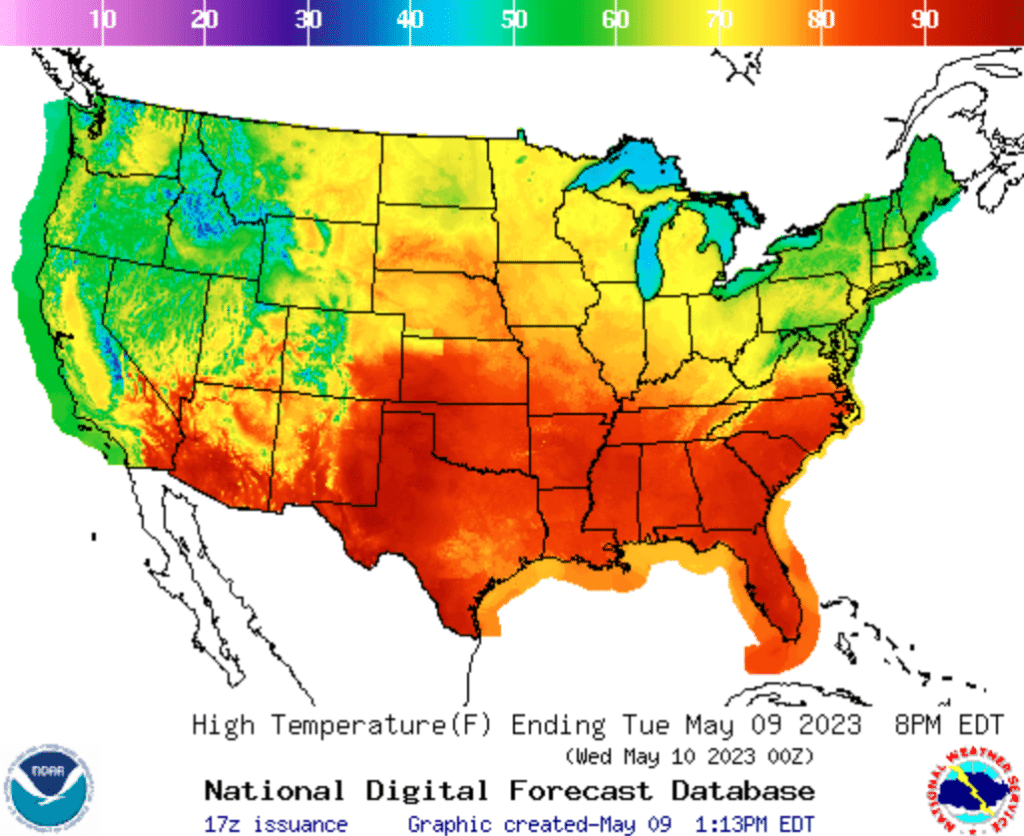

#### <font color= "darkolivegreen"> **¿Para qué nos sirven?**

Los mapas de calor son especialmente *útiles para analizar datos espaciales, matrices de correlación o campos continuos, ya que permiten observar rápidamente la distribución de los valores en una superficie*. En el análisis científico y ambiental, por ejemplo, pueden emplearse para visualizar campos de temperatura, precipitación o humedad sobre una región geográfica. 

#### <font color="darkolivegreen"> **¿Cómo creamos un heatmap?**
En Matplotlib, los **heatmaps** se suelen construir con funciones como `imshow()` o `pcolormesh()`, y normalmente se acompañan de una barra de colores (colorbar) que muestra la relación entre los colores y los valores numéricos.


####  <font color="darkorange"> **Ejemplo 1: `imshow()`**


<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html>

In [29]:
#Comúnmente, los heatmaps se crean con matrices 2D

#Vamos a crear un conjunto de datos que supondremos que son anomalías en el campo magnético de la tierra, medidos desde diversos
# puntos de México

#Creamos datos que simulen las mediciones para cada estacion
anomalias = np.array([
[-5,-10,-15,-10,-5], #Cada fila representa la latitud de cada estación
[-20,-30,-20,-10,10], #Cada columna la longitud
[-30,-50,-30,-15,25],
[-10,-20,-30,-20,-10],
[-10,-15,-10,-5,0]
])

#Vamos a ver la forma del arreglo

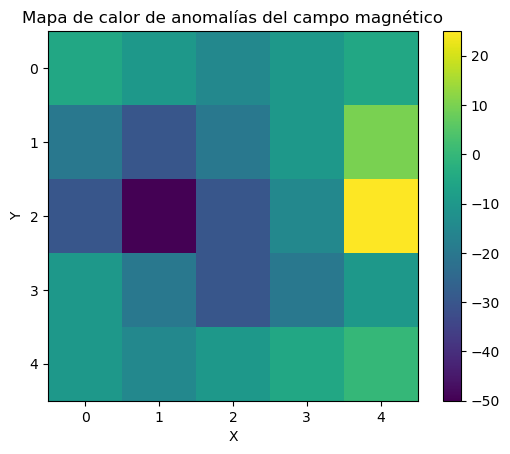

In [30]:
#Agregando barra de color

plt.imshow(anomalias) #Datos

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de calor de anomalías del campo magnético")
plt.colorbar() #Por default, el ticks superior de la barra es el valor máximo y el inferior el mínimo

#### <font color="darkblue"> **Personalización**

* Colormaps (<https://matplotlib.org/stable/users/explain/colors/colormaps.html>)

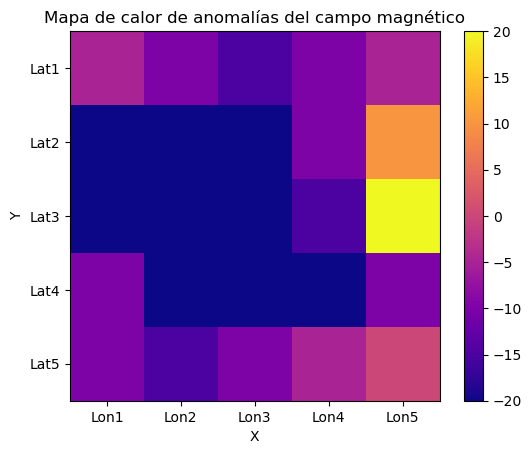

In [31]:
#Queremos cambiar de colormap, la simetría de la barra y personalizar las etiquetas

#Para que el colorbar sea simétrico es necesario definir los mismos límites pero con signo contrario
valor_minimo=-20
valor_maximo=20

#Definimos el nombre de las etiquetas
etiquetas_x=["Lon1","Lon2","Lon3","Lon4","Lon5"]
etiquetas_y=["Lat1","Lat2","Lat3","Lat4","Lat5"]

plt.imshow(anomalias,
           cmap="plasma", #Cambiar color map
           vmin=valor_minimo, #Límite mínimo de la barra
           vmax=valor_maximo #Límite máximo de la barra
          )

#Usamos ticks para modificar las etiquetas de los ejes
plt.xticks(np.arange(5), etiquetas_x)
plt.yticks(np.arange(5), etiquetas_y)


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de calor de anomalías del campo magnético")
plt.colorbar()
plt.savefig('campomagnetico.png',dpi=150)

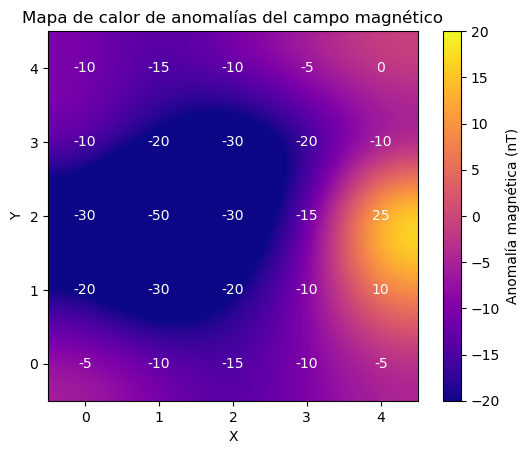

In [32]:
#Más personalizaciones
plt.imshow(anomalias,
           cmap="plasma", 
           vmin=valor_minimo, 
           vmax=valor_maximo,
           origin="lower", #Controla dónde empieza la matriz, por default "upper"
           interpolation="bicubic"  #Suaviza los pixeles ("nearest","bilinear",bicubic")
          )

#Para agregar los valores de las anomalías
for i in range(anomalias.shape[0]):
    for j in range(anomalias.shape[1]):
        plt.text(j, i, anomalias[i,j],
                 ha="center", #Alineación horizontal
                 va="center", #Alineación vertical
                 color="white")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de calor de anomalías del campo magnético")
plt.colorbar(label="Anomalía magnética (nT)") #Podemos agregar etiqueta a la barra
plt.savefig('nicefig.png',dpi=300)

####  <font color="darkorange"> **Ejemplo 2: `pcolormesh()`**

La función `pcolormesh()` de Matplotlib también sirve para hacer mapas de calor, pero a diferencia de `imshow()` es mucho más usada en Ciencias de la Tierra porque permite trabajar con coordenadas reales (latitud, longitud, distancia, etc.).

Comúnmente, cuando se trabaja con datos de NetCDF o xarray, casi siempre se usa `pcolormesh()`.

In [33]:
#Retomando el ejemplo anterior

#Paso 1: Definimos las coordenadas de nuestros datos (latitud,longitud)
x = np.linspace(-119,-110,5) #Longitud
y = np.linspace(14,20,5) #Latitud

Para poder graficar algo en 2D, necesitamos un arreglo de 2D. Para generar un arreglo 2D podemos utilizar la función de numpy `meshgrid`.

La función `np.meshgrid` en NumPy se utiliza para crear matrices de coordenadas a partir de matrices unidimensionales, lo que es particularmente útil para generar mallas de puntos en 2D para su posterior uso en gráficos tridimensionales, interpolación de datos, y cálculos vectoriales.

Cuando se aplica np.meshgrid a dos o más arrays unidimensionales, devuelve matrices multidimensionales donde cada dimensión representa un conjunto de coordenadas. Por ejemplo, si tienes dos arrays unidimensionales $x$ y $y$, `np.meshgrid(x, y)` generará dos matrices bidimensionales, una correspondiente a las coordenadas y otra a las coordenadas.

Las salidas de `np.meshgrid` son útiles para operaciones que involucran manipulación de coordenadas, como trazado de gráficos en 3D, evaluación de funciones en una cuadrícula de puntos, interpolación de datos, cálculos de derivadas parciales y más.

En resumen, `np.meshgrid` es una función fundamental para la creación de mallas de puntos en 2D a partir de arrays unidimensionales, lo que facilita la representación visual de datos y cálculos vectoriales en el espacio bidimensional.

In [34]:
#Arreglo 2D
Lon,Lat=np.meshgrid(x,y) #Se utiliza para transformar vectores unidimensionales de coordenadas en matrices multidimensionales

Text(0.5, 1.0, 'Mapa de calor de anomalías del campo magnético')

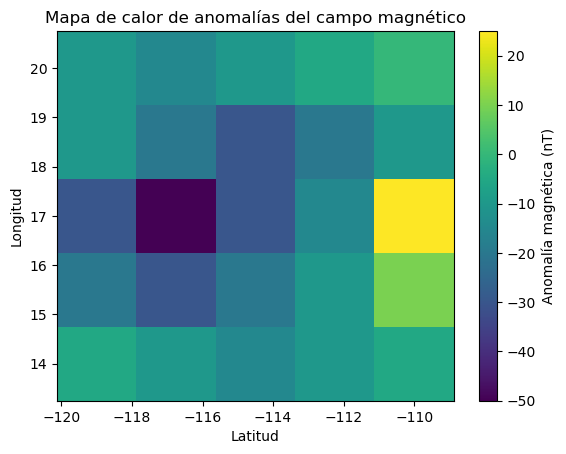

In [35]:
#Paso 3: Graficar el mapa de calor

plt.pcolormesh(Lon,Lat,anomalias) #Tengo que colocar las coordenadas de mis datos (x,y) y los datos a graficar
plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title("Mapa de calor de anomalías del campo magnético")

#### <font color="darkblue"> **Personalización**

Text(0.5, 1.0, 'Mapa de calor de anomalías del campo magnético')

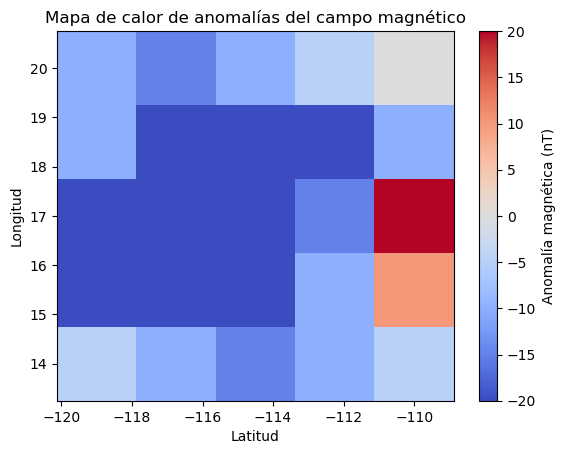

In [36]:
plt.pcolormesh(Lon,Lat,anomalias,
              cmap="coolwarm",  #Colormap diferente
              vmin= -20,        #Valor mínimo
              vmax=20,           #Valor máximo
              shading="auto"     #Controla cómo se dibujan las celdas ("auto"[recomendado], "nearest", "gouraud")
              ) 

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title("Mapa de calor de anomalías del campo magnético")

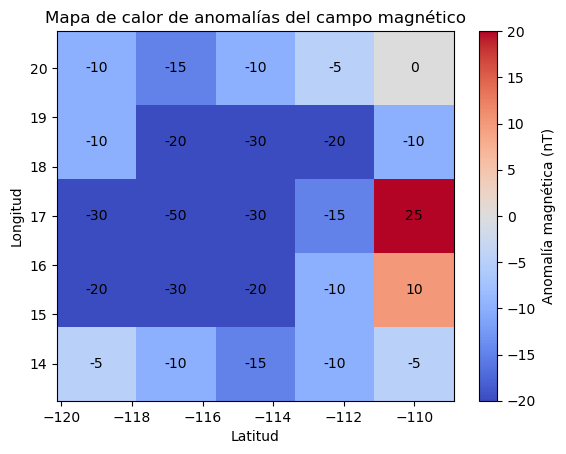

In [37]:
#Quiero agregar los valores exactos de la anomalía para cada cuadrícula
plt.pcolormesh(Lon,Lat,anomalias,
              cmap="coolwarm",  
              vmin= -20,        
              vmax=20,           
              shading="auto"     
              ) 

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title("Mapa de calor de anomalías del campo magnético")

#Usamos un ciclo for y ocupamos plt.text()
for i in range(anomalias.shape[0]):
    for j in range(anomalias.shape[1]):
        plt.text(Lon[i,j], Lat[i,j], anomalias[i,j],
                 ha="center",
                 va="center",
                 color="black")
plt.savefig('campomagneticov2.png',dpi=150)

### <font color="brown"> **Diferencias entre `imshow()` y `pcolormesh()`**

| Característica | `imshow()`                     | `pcolormesh()`                   |
| -------------- | ------------------------------ | -------------------------------- |
| Tipo de datos  | matriz tratada como **imagen** | matriz en **coordenadas reales** |
| Ejes           | usa **índices de la matriz**   | usa **X y Y explícitos**         |
| Velocidad      | **más rápido**                 | un poco **más lento**            |
| Uso típico     | imágenes, matrices             | mapas científicos                |
| Geociencias    | menos usado                    | **muy usado**                    |
| Celdas         | píxeles                        | cuadrículas                      |


-----

### <font color="DodgerBlue">Ejercicio 2: imshow vs pcolormesh</font>

1. Genera una matriz de datos 2D (por ejemplo, una malla con `np.random.rand(20, 30)` o usando `np.meshgrid` + una función simple).
2. Grafica la matriz usando `imshow`, agregando título y barra de color.
3. Grafica la misma matriz usando `pcolormesh`, también con barra de color.
4. Personaliza ambas figuras (colormap, labels, etc.) y compara: ¿qué diferencias observas?
5. Guarda tu figura en tu carpeta de plots.

-----

## <font color="ForestGreen">Introducción a Seaborn: Análisis Exploratorio de Datos</font>


![image.png](attachment:image.png)

**Seaborn** es una librería de visualización en Python construida sobre matplotlib que facilita el **análisis exploratorio de datos (EDA)** mediante gráficas estadísticas claras, elegantes y rápidas de generar.

Su principal ventaja es que permite visualizar **relaciones, distribuciones y patrones** en los datos con muy poco código.

---

### ¿Para qué usamos Seaborn?

En análisis exploratorio queremos responder preguntas como:

- ¿Cómo se distribuyen mis datos?
- ¿Existen relaciones entre variables?
- ¿Hay agrupamientos o diferencias entre categorías?
- ¿Existen valores atípicos?

Seaborn nos ayuda a responder estas preguntas visualmente.

---

### Instalación e importación

```python
import seaborn as sns


```

In [38]:
import seaborn as sns

In [39]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


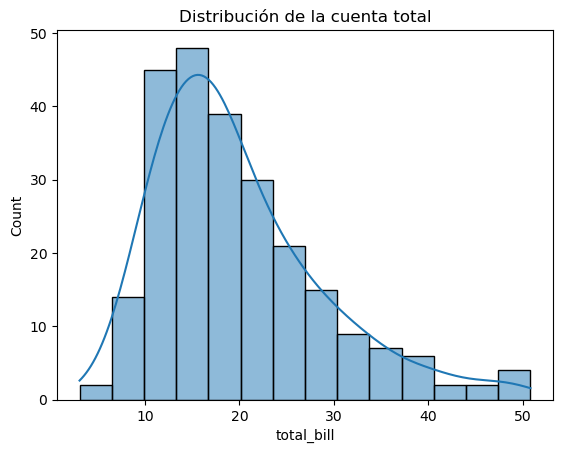

In [47]:
sns.histplot(data=df, x="total_bill", kde=True)
plt.title("Distribución de la cuenta total")
plt.savefig('cuentaseaborn.png',dpi=150)

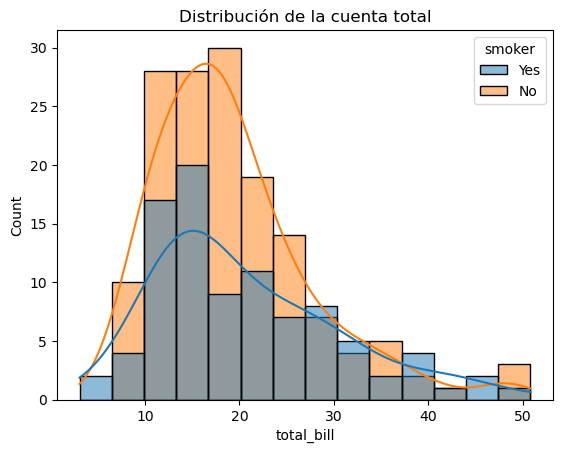

In [48]:
sns.histplot(data=df, x="total_bill", kde=True,hue='smoker')
plt.title("Distribución de la cuenta total")
plt.savefig('cuentaseaborn2.png',dpi=150)

Text(0.5, 1.0, 'Cuenta total por día')

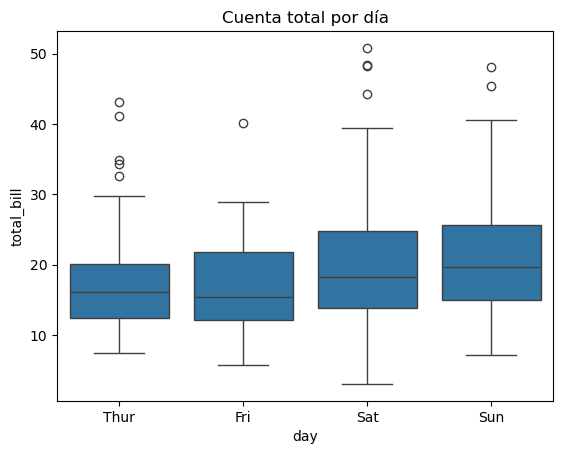

In [49]:
sns.boxplot(data=df, x="day", y="total_bill")
plt.title("Cuenta total por día")

Text(0.5, 1.0, 'Propina vs Cuenta total')

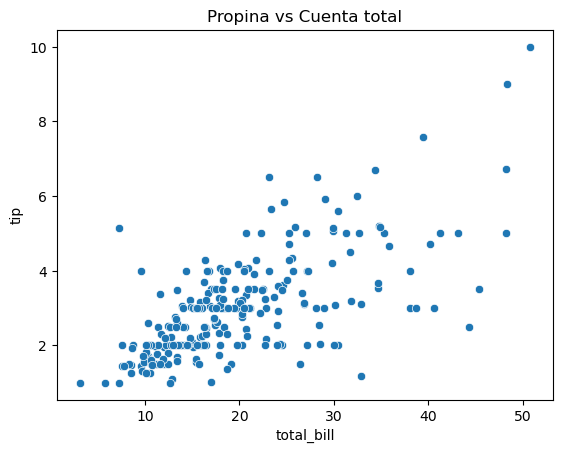

In [43]:
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.title("Propina vs Cuenta total")

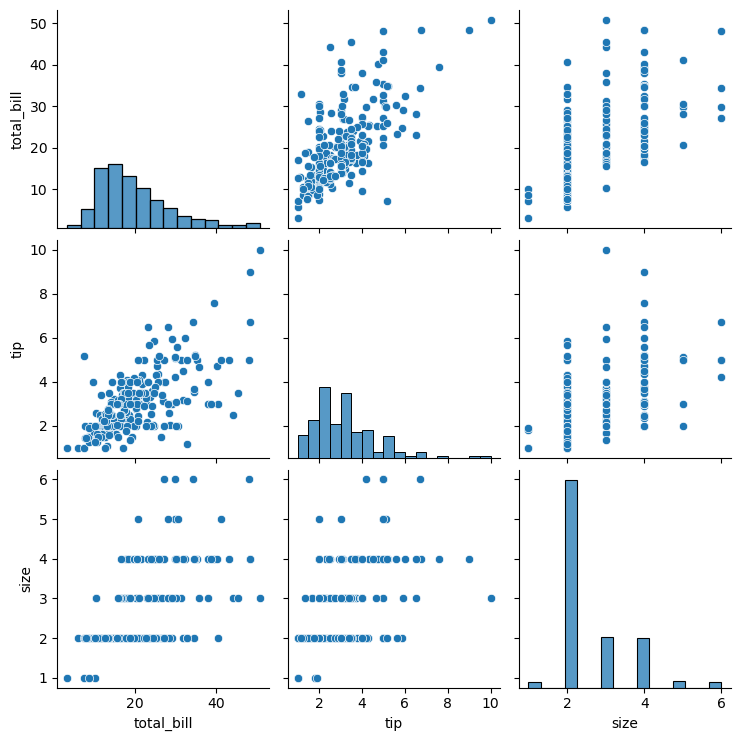

In [44]:
sns.pairplot(df)